# 检索优化

本文完整的使用milvus中来检索向量，使用了混合检索

# 稀疏向量 和 密集向量

## 稀疏向量

稀疏向量，由于“番茄”和“西红柿”是不同的词条（索引不同），模型将无法理解它们的语义相似性。

假设在一个包含5万个词的词汇表中，“西红柿”在第88位，“炒”在第666位，“蛋”在第999位，它们的BM25权重分别是1.2、0.8、1.5。那么它的稀疏表示（采用字典格式）就是：

// {索引: 权重}
{
  "88": 1.2,
  "666": 0.8,
  "999": 1.5
}

## 密集向量

一个预训练好的语义模型在读取“西红柿炒蛋”后，会输出一个低维的密集向量：

// 这是一个低维（比如1024维）的浮点数向量
// 向量的每个维度没有直接的、可解释的含义
[0.89, -0.12, 0.77, ..., -0.45]


## 各有优点

 关键词检索无法理解语义，而向量检索则可能忽略掉必须精确匹配的关键词（如产品型号、函数名等）。混合检索旨在同时利用稀疏向量的精确性和密集向量的泛化性，以应对复杂多变的搜索需求。

# 混合检索技术

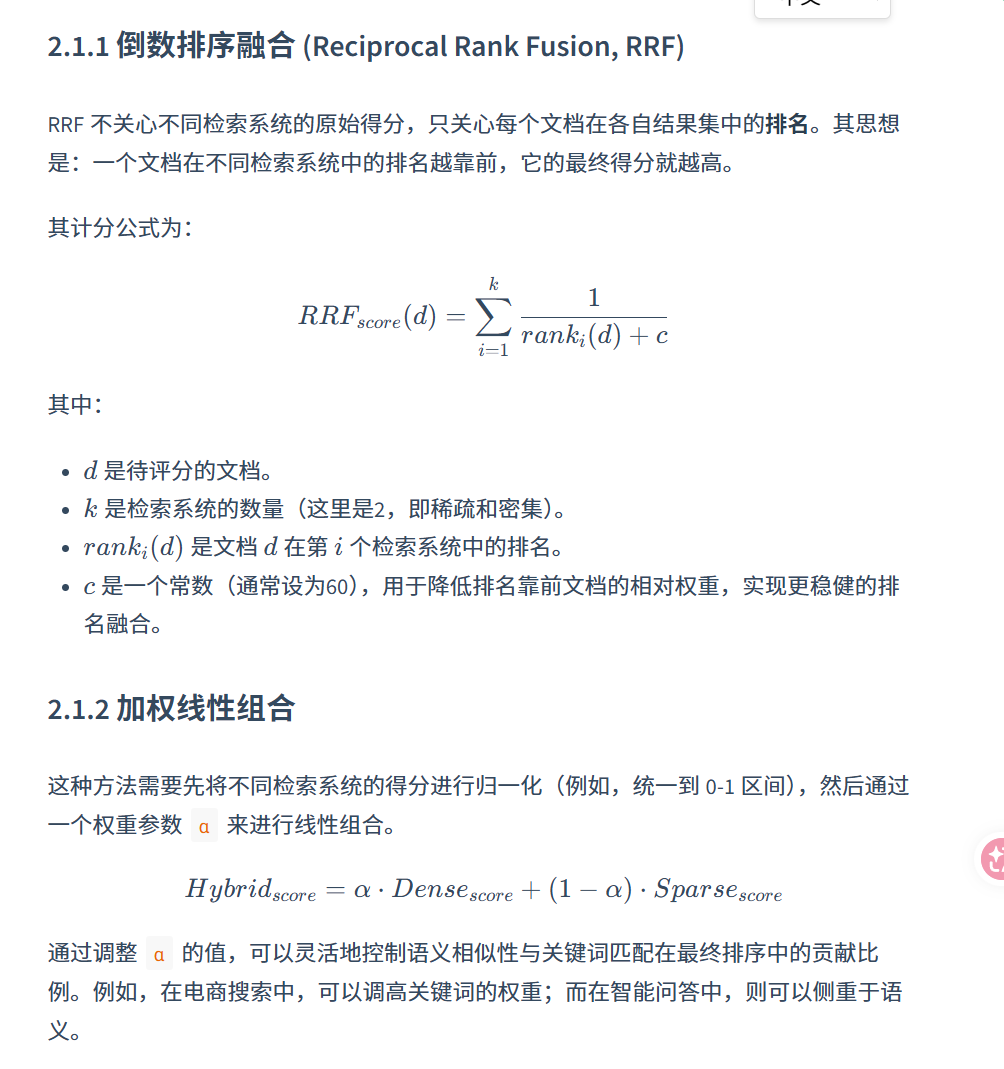

# 代码实现

In [1]:
import json
import os 
# 在导入huggingface的包之前设置下，下载路径
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
import numpy as np
from pymilvus import connections, MilvusClient, FieldSchema, Collection,DataType, CollectionSchema

# 这里把智源的向量模型引入进来， 他可以同时生成稀疏和密集向量
from pymilvus.model.hybrid import BGEM3EmbeddingFunction


In [2]:
# 参数设置
COLLECTION_NAME = "dragon_hybrid_demo"
MILVUS_URI = "http://localhost:19530"  # 服务器模式
DATA_PATH = "./data/C4/metadata/dragon.json"  # 相对路径
BATCH_SIZE = 50

In [14]:
# 初始化BGE-M3模
ef = BGEM3EmbeddingFunction(use_fp16=False, device="cpu")

Fetching 30 files:   0%|          | 0/30 [00:00<?, ?it/s]

In [4]:
milvus_client = MilvusClient(uri=MILVUS_URI)
if milvus_client.has_collection(COLLECTION_NAME):
    milvus_client.drop_collection(COLLECTION_NAME)

In [5]:
fields = [
    FieldSchema(name="pk", dtype=DataType.VARCHAR, is_primary=True, auto_id=True, max_length=100),
    FieldSchema(name="img_id", dtype=DataType.VARCHAR, max_length=100),
    FieldSchema(name="path", dtype=DataType.VARCHAR, max_length=256),
    FieldSchema(name="title", dtype=DataType.VARCHAR, max_length=256),
    FieldSchema(name="description", dtype=DataType.VARCHAR, max_length=4096),
    FieldSchema(name="category", dtype=DataType.VARCHAR, max_length=64),
    FieldSchema(name="location", dtype=DataType.VARCHAR, max_length=128),
    FieldSchema(name="environment", dtype=DataType.VARCHAR, max_length=64),
    FieldSchema(name="sparse_vector", dtype=DataType.SPARSE_FLOAT_VECTOR),
    FieldSchema(name="dense_vector", dtype=DataType.FLOAT_VECTOR, dim=ef.dim["dense"])
]

下面是给collection创建索引和属性

属性直接通过schema创建，然后create index来创建索引

In [6]:
# 运行前需要运行docker 并且把milvus运行起来
# 链接Milvus
connections.connect(uri = MILVUS_URI)

if not milvus_client.has_collection(COLLECTION_NAME):
    print(f"--> 正在创建 Collection '{COLLECTION_NAME}'...")
    schema = CollectionSchema(fields, description = "混合检索")
    collection = Collection(name = COLLECTION_NAME, schema = schema, consconsistency_level="Strong")
    
    # 下面创建稀疏向量索引
    sparse_index = {
        "index_type" : "SPARSE_INVERTED_INDEX", # 指定索引为稀疏索引
        "metric_type": "IP" # 内积
    }
    
    # 字段创建索引，第一个变量是字典中的列名，第二个变量是创建索引的配方
    collection.create_index("sparse_vector", sparse_index)

    # 下面创建密集索引
    dense_index = {"index_type" :"AUTOINDEX",  "metric_type": "IP"}
    collection.create_index("dense_vector", dense_index)
    
# 拿到collection
collection = Collection(COLLECTION_NAME)
collection.load() # 把collection加载到内存

--> 正在创建 Collection 'dragon_hybrid_demo'...


## BGE-M3双向量生成

这里collection此时加载到内存中，把文本当中的多个字段的文本合并到实体中的一个完整的数据记录

这里就是把所有的文本给我合并

In [ ]:
if collection.is_empty:
    with open(DATA_PATH, "r", encoding = "utf-8") as f :
        dataset = json.load(f)
        
    docs, metadata = [], []
    for item in dataset : 
        parts = [
            item.get("title", ""),
            item.get('description', ''),
            item.get('location', ''),
            item.get('environment', ''),
        ]
        
        # 这里filter 第一个参数None可以吧空，0，空格这种无意义的字符给去掉， 然后通过空格进行连接
        docs.append(" ".join(filter(None, parts)))
        metadata.append(item)
        

In [ ]:
metadata[0]

{'img_id': 'dragon02',
 'path': '../../data/C3/dragon/dragon02.png',
 'title': '悬崖上的白龙',
 'description': '一头雄伟的白色巨龙栖息在悬崖边缘，背景是金色的云霞和远方的海岸。它拥有巨大的翅膀和优雅的身姿，是典型的西方奇幻生物。',
 'category': 'western_dragon',
 'location': '悬崖海岸',
 'environment': '天空'}

In [12]:
docs[0]

'悬崖上的白龙 一头雄伟的白色巨龙栖息在悬崖边缘，背景是金色的云霞和远方的海岸。它拥有巨大的翅膀和优雅的身姿，是典型的西方奇幻生物。 悬崖海岸 天空'

## 向量生成

In [ ]:
# 把文本放入到嵌入向量模型当中，然后把结果输出出来
embeddings = ef(docs)

# 注意这里！名字千万别对应错！
dense_vectors = embeddings["dense"]   # 提取稠密向量
sparse_vectors = embeddings["sparse"] # 提取稀疏向量

## Collection 批量数据插入

In [ ]:
# 为每个字段准备批量数据
img_ids = [doc["img_id"] for doc in metadata]
paths = [doc["path"] for doc in metadata]
titles = [doc["title"] for doc in metadata]
descriptions = [doc["description"] for doc in metadata]
categories = [doc["category"] for doc in metadata]
locations = [doc["location"] for doc in metadata]
environments = [doc["environment"] for doc in metadata]

# 插入数据，这里插入数据的顺序一定要和schema相同
collection.insert([
    img_ids, paths, titles, descriptions, categories, locations, environments,
    sparse_vectors, dense_vectors
])

# 强制将内存缓冲区写入到磁盘，索引蹭使用稀疏向量
collection.flush()

## 使用混合检索

使用milvus中封装好的排序算法进行混合检索 

### 查询向量生成

In [19]:
# 这里是客户的自然语言的查询
search_query = "悬崖上的巨龙"

# 这里是milvus的过滤功能，有点像SQL语言
search_filter = 'category in ["western_dragon", "chinese_dragon", "movie_character"]'
# 拿到最像的5条
top_k = 5

In [20]:
# 搜索
query_embeddings = ef([search_query])

# 取出数据
dense_vec = query_embeddings["dense"][0]
sparse_vec = query_embeddings["sparse"]._getrow(0) # 这里sparse为了节省空间用了非常的手段，所以这里取值的时候需要使用特殊的函数


### 先单独检索

In [23]:
# 定义搜索中的这些参数应该怎么写
search_params = {"metric_type": "IP", "params": {}}

# 执行单独的搜索
dense_results = collection.search(
    [dense_vec],
    anns_field="dense_vector",
    param = search_params,
    limit=top_k,
    expr=search_filter,
    ooutput_fields=["title", "path", "description", "category", "location", "environment"]
)[0]

print("\n--- [单独] 稀疏向量搜索结果 ---")
sparse_results = collection.search(
    [sparse_vec],
    anns_field="sparse_vector",
    param=search_params,
    limit=top_k,
    expr=search_filter,
    output_fields=["title", "path", "description", "category", "location", "environment"]
)[0]

for i, hit in enumerate(sparse_results):
    print(f"{i+1}. {hit.entity.get('title')} (Score: {hit.distance:.4f})")
    print(f"    路径: {hit.entity.get('path')}")
    print(f"    描述: {hit.entity.get('description')[:100]}...")


--- [单独] 稀疏向量搜索结果 ---
1. 悬崖上的白龙 (Score: 0.2254)
    路径: ../../data/C3/dragon/dragon02.png
    描述: 一头雄伟的白色巨龙栖息在悬崖边缘，背景是金色的云霞和远方的海岸。它拥有巨大的翅膀和优雅的身姿，是典型的西方奇幻生物。...
2. 中华金龙 (Score: 0.0857)
    路径: ../../data/C3/dragon/dragon06.png
    描述: 一条金色的中华龙在祥云间盘旋，它身形矫健，龙须飘逸，展现了东方神话中龙的威严与神圣。...
3. 驯龙高手：无牙仔 (Score: 0.0639)
    路径: ../../data/C3/dragon/dragon05.png
    描述: 在电影《驯龙高手》中，主角小嗝嗝骑着他的龙伙伴无牙仔在高空飞翔。他们飞向灿烂的太阳，下方是岛屿和海洋，画面充满了冒险与友谊。...


### 混合检索

RRF检索是平缓系数k 和 检索出来的排名综合进行计算的

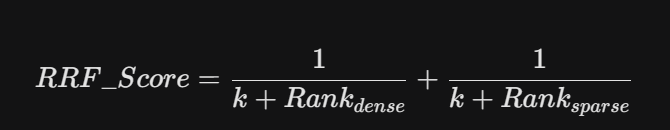

In [22]:
from pymilvus import RRFRanker # 别忘了导入裁判和包裹包
from pymilvus import AnnSearchRequest

rerank = RRFRanker(k=60)

# 在混合检索之前，需要把密集检索的向量和稀疏向量给包裹成一个AnnSearchRequest类
dense_req = AnnSearchRequest([dense_vec], "dense_vector", search_params, limit=top_k)
sparse_req = AnnSearchRequest([sparse_vec], "sparse_vector", search_params, limit=top_k)

results = milvus_client.hybrid_search(
    COLLECTION_NAME,
    [sparse_req, dense_req], # 看这里！把两个包裹装进列表，一起塞进去！
    ranker=RRFRanker(60),# 请出 RRF 裁判来算总分
    limit=top_k,
    output_fields=["title", "path", "description", "category", "location", "environment"]
)[0]

# 打印最终结果
for i, hit in enumerate(results):
    print(f"{i+1}. {hit.entity.get('title')} (Score: {hit.distance:.4f})")
    print(f"    路径: {hit.entity.get('path')}")
    print(f"    描述: {hit.entity.get('description')[:100]}...")

1. 悬崖上的白龙 (Score: 0.0328)
    路径: ../../data/C3/dragon/dragon02.png
    描述: 一头雄伟的白色巨龙栖息在悬崖边缘，背景是金色的云霞和远方的海岸。它拥有巨大的翅膀和优雅的身姿，是典型的西方奇幻生物。...
2. 中华金龙 (Score: 0.0320)
    路径: ../../data/C3/dragon/dragon06.png
    描述: 一条金色的中华龙在祥云间盘旋，它身形矫健，龙须飘逸，展现了东方神话中龙的威严与神圣。...
3. 奔跑的奶龙 (Score: 0.0315)
    路径: ../../data/C3/dragon/dragon04.png
    描述: 一只Q版的黄色小恐龙，有着大大的绿色眼睛和友善的微笑。是一部动画中的角色，非常可爱。...
4. 驯龙高手：无牙仔 (Score: 0.0313)
    路径: ../../data/C3/dragon/dragon05.png
    描述: 在电影《驯龙高手》中，主角小嗝嗝骑着他的龙伙伴无牙仔在高空飞翔。他们飞向灿烂的太阳，下方是岛屿和海洋，画面充满了冒险与友谊。...
5. 霸王龙的怒吼 (Score: 0.0312)
    路径: ../../data/C3/dragon/dragon03.png
    描述: 史前时代的霸王龙张开血盆大口，发出震天的怒吼。在它身后，几只翼龙在阴沉的天空中盘旋，展现了白垩纪的原始力量。...
